In [13]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import basis, coherent, destroy, expect, mesolve, qeye, sigmax, sigmaz, tensor

In [26]:
N = 20
wr = 5.0 * 2 * np.pi
wq = 4.0 * 2 * np.pi
chi = 0.025 * 2 * np.pi
delta = abs(wr - wq)
g = np.sqrt(delta * chi)

print(f"delta/2pi = {delta / (2 * np.pi):.3f} GHz")
print(f"g/2pi     = {g / (2 * np.pi):.3f} GHz")
print(f"delta/g  = {delta / g:.3f}")

# cavity operators
a = tensor(destroy(N), qeye(2))
nc = a.dag() * a
xc = a + a.dag()

# qubit operators
sm = tensor(qeye(N), destroy(2))
sz = tensor(qeye(N), sigmaz())
sx = tensor(qeye(N), sigmax())
nq = sm.dag() * sm
xq = sm + sm.dag()
Id = tensor(qeye(N), qeye(2))

H = (wr * (a.dag() * a + Id / 2.0) + (wq / 2.0) * sz + chi * (a.dag() * a + Id / 2.0) * sz)
psi0 = tensor(coherent(N, np.sqrt(4)), (basis(2, 0) + basis(2, 1)).unit())
tlist = np.linspace(0, 200, 1000)
res = mesolve(H, psi0, tlist, c_ops=[], e_ops=[], options={"nsteps": 5000})
n_qubit = expect(nq, res.states)
n_cavity = expect(nc, res.states)
qubit_z = expect(sz, res.states)

delta/2pi = 1.000 GHz
g/2pi     = 0.158 GHz
delta/g  = 6.325


## Evolution of the number operators

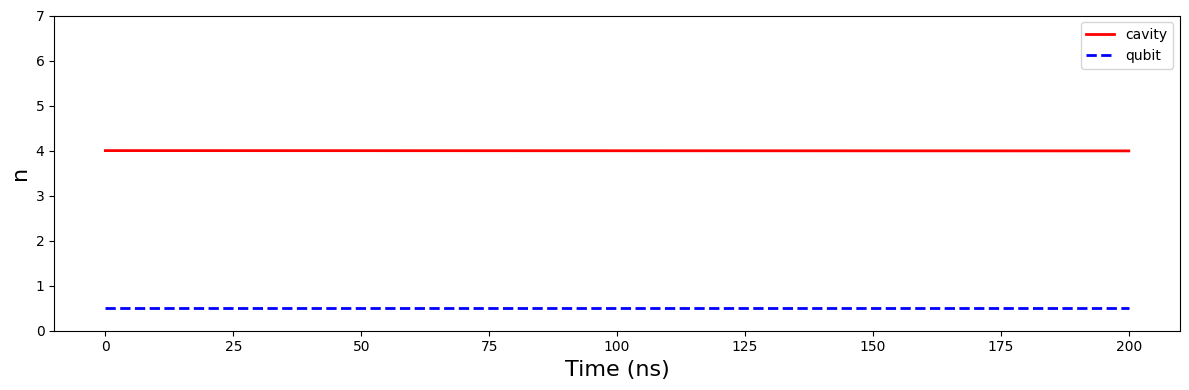

In [27]:
fig, ax = plt.subplots(1, 1, sharex=True, figsize=(12, 4))

ax.plot(tlist, n_cavity, "r", linewidth=2, label="cavity")
ax.plot(tlist, n_qubit, "b--", linewidth=2, label="qubit")
ax.set_ylim(0, 7)
ax.set_ylabel("n", fontsize=16)
ax.set_xlabel("Time (ns)", fontsize=16)
ax.legend()
fig.tight_layout()